## Contexto

Eres dueño de un centro comercial de supermercados y, a través de tarjetas de membresía, tienes algunos datos básicos sobre tus clientes, como el ID del cliente, edad, género, ingreso anual y puntuación de gasto (Spending Score). La puntuación de gasto es algo que asignas al cliente basado en tus parámetros definidos como el comportamiento del cliente y los datos de compra.

**Declaración del Problema**

Eres dueño del centro comercial y deseas comprender a los clientes, como quiénes pueden ser fácilmente captados [Clientes Objetivo], para que la información pueda ser enviada al equipo de marketing y planificar la estrategia en consecuencia.

**Preguntas**:
1. ¿Cómo lograr la segmentación de clientes utilizando un algoritmo de aprendizaje automático (KMeans Clustering) en Python de la manera más sencilla?
2. ¿Quiénes son tus clientes objetivo con quienes puedes comenzar la estrategia de marketing [fácil de captar]?


*¿Cómo funciona la estrategia de marketing en el mundo real?*

## Aprendizaje No Supervisado: Descubriendo Patrones Ocultos

El aprendizaje no supervisado es una rama del aprendizaje automático que trabaja con datos no etiquetados. A diferencia del aprendizaje supervisado, donde los datos vienen con etiquetas predefinidas (por ejemplo, "gato" o "perro" en imágenes), los algoritmos de aprendizaje no supervisado descubren patrones y estructuras ocultas dentro de los datos por sí mismos.

**Comparación con el Aprendizaje Supervisado:**

| Característica    | Aprendizaje Supervisado | Aprendizaje No Supervisado |
|-------------------|-------------------------|----------------------------|
| Datos             | Etiquetados (con categorías predefinidas) | No etiquetados (sin categorías predefinidas) |
| Tarea             | Clasificación, Regresión | Clustering, Reducción de Dimensionalidad, Detección de Anomalías |
| Objetivo          | Aprender una relación entre entrada y salida | Descubrir patrones ocultos en los datos |
| Interpretación del Modelo | Más fácil de interpretar basado en etiquetas | Más desafiante, requiere conocimiento del dominio |

**Importancia del Aprendizaje No Supervisado:**

- **Exploración y Descubrimiento:** Ayuda a revelar estructuras, relaciones y anomalías ocultas que podrían pasarse por alto en datos etiquetados.
- **Preparación de Datos:** Técnicas como la reducción de dimensionalidad pueden preparar los datos para un análisis más profundo en tareas supervisadas.
- **Eficiencia:** El aprendizaje no supervisado puede ser menos intensivo en recursos que el supervisado, ya que no requiere la etiqueta manual de datos.

**Aplicaciones en la Industria:**

1. **Sistemas de Recomendación:** Analizar el comportamiento del usuario y los atributos de los productos para recomendar artículos relevantes (por ejemplo, Netflix, Amazon).
2. **Segmentación de Clientes:** Agrupar a los clientes en función de características similares para campañas de marketing dirigidas.
3. **Detección de Anomalías:** Identificar patrones inusuales en el tráfico de redes, transacciones financieras o datos de sensores para la prevención de fraudes o el mantenimiento de sistemas.
4. **Análisis de Imágenes y Texto:** Descubrir temas en documentos, agrupar imágenes en función de su contenido o identificar objetos en imágenes.
5. **Procesamiento de Lenguaje Natural (NLP):** Aprender representaciones de palabras y relaciones entre ellas para mejorar modelos de lenguaje o análisis de sentimientos.

**Ejemplos del Mundo Real:**

- **Redes Sociales:** El clustering no supervisado puede agrupar a usuarios con intereses similares, facilitando la publicidad dirigida.
- **Astronomía:** Identificación de grupos de galaxias o clasificación de objetos celestiales según sus propiedades.
- **Diagnóstico Médico:** Detección de anomalías en escaneos médicos o datos de pacientes que podrían indicar problemas de salud potenciales.
- **Mercados Financieros:** El aprendizaje no supervisado se puede utilizar para identificar actividades fraudulentas o predecir tendencias del mercado basadas en datos históricos.

### Entendiendo el Aprendizaje No Supervisado

Imagina una canasta llena de frutas sin categorizar. El aprendizaje supervisado sería como tener cada fruta etiquetada como "manzana," "naranja" o "plátano." Sin embargo, el aprendizaje no supervisado analizaría las frutas en función de su color, tamaño y textura para agruparlas en categorías similares, sin conocimiento previo de sus nombres.

### Agrupamiento con K-Means

K-Means es un algoritmo de clustering que divide los puntos de datos en un número predefinido de clústeres (k). A continuación, te mostramos un ejemplo utilizando la biblioteca scikit-learn:

K-Means es un algoritmo de agrupamiento (clustering) que busca dividir un conjunto de datos en \( k \) grupos o clústeres. La idea principal es encontrar los "centroides" de estos clústeres, que representan el centro de cada grupo.

### Proceso Matemático:

1. **Inicialización**: Elegimos $ k $ puntos al azar que servirán como centroides iniciales.
   
2. **Asignación de puntos**: Para cada punto de datos, calculamos la distancia euclidiana a cada uno de los centroides y lo asignamos al clúster más cercano. Matemáticamente, para un punto $ x_i$ y un centroide $\mu_j $:
   $
   \text{distancia}(x_i, \mu_j) = \sqrt{\sum_{d=1}^{n} (x_{id} - \mu_{jd})^2}
   $
   donde $ n $ es la dimensión del punto.

3. **Actualización de centroides**: Recalculamos los centroides tomando el promedio de todos los puntos asignados a cada clúster:
  $
   \mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i
   $
   donde $C_j $ es el conjunto de puntos asignados al clúster $ j $.

4. **Repetición**: Repetimos los pasos de asignación y actualización hasta que los centroides no cambien significativamente o hasta que se alcance un número máximo de iteraciones.

### Intuición:

K-Means busca minimizar la **varianza intra-clúster**, es decir, intenta que los puntos dentro de un clúster estén lo más cerca posible de su centroide. Al mismo tiempo, maximiza la distancia entre los diferentes clústeres, para que los grupos sean lo más distintos posibles.

Es un algoritmo intuitivo porque basa la agrupación en la similitud (distancia) entre puntos y es eficiente para encontrar patrones en los datos sin supervisión.


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2" # export OMP_NUM_THREADS=4
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline   
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

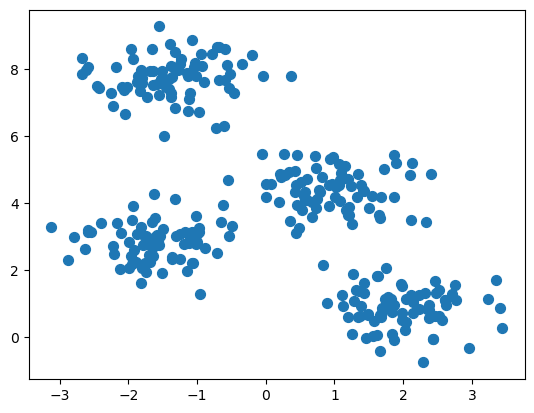

In [2]:
# Generar datos de muestra
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')

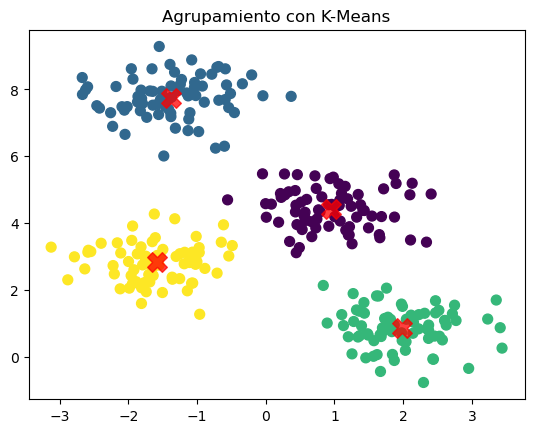

In [3]:
# Aplicar KMeans
kmeans = KMeans(n_clusters=4,n_init=2)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Visualizar los clústeres
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Marcar los centroides
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('Agrupamiento con K-Means')
plt.show()

Para evaluar la calidad de los clústeres generados por el algoritmo K-Means y hacer comparaciones con diferentes números de grupos usaremos la **inercia** (distancia intra-clúster) y el **coeficiente de silueta** como métricas de evaluación:


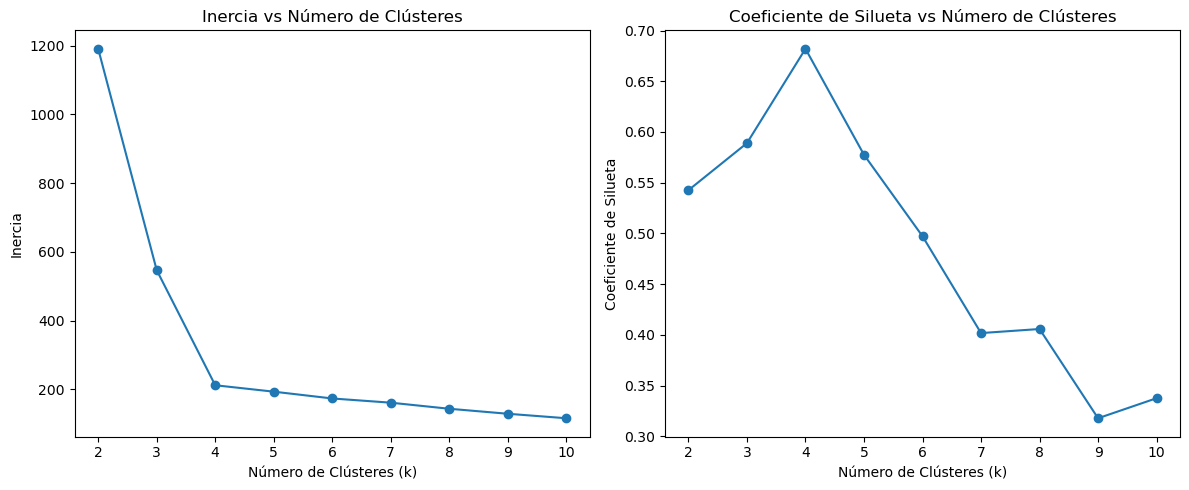

In [4]:
from sklearn.preprocessing import LabelEncoder

# Generar datos de muestra
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=0)

# Rango de número de clústeres a evaluar
k_values = range(2, 11)

# Lista para almacenar las inercia y coeficiente de silueta
inertia = []
silhouette_scores = []

for k in k_values:
    # Aplicar KMeans con k clústeres
    kmeans = KMeans(n_clusters=k, random_state=0,n_init=2)
    kmeans.fit(X)
    
    # Guardar la inercia (suma de las distancias intra-clúster)
    inertia.append(kmeans.inertia_)
    
    # Predecir los clústeres
    y_kmeans = kmeans.predict(X)
    
    # Calcular el coeficiente de silueta (para k > 1)
    silhouette_avg = silhouette_score(X, y_kmeans)
    silhouette_scores.append(silhouette_avg)

# Graficar la inercia y el coeficiente de silueta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de la inercia
ax1.plot(k_values, inertia, marker='o')
ax1.set_title('Inercia vs Número de Clústeres')
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Inercia')

# Gráfico del coeficiente de silueta
ax2.plot(k_values, silhouette_scores, marker='o')
ax2.set_title('Coeficiente de Silueta vs Número de Clústeres')
ax2.set_xlabel('Número de Clústeres (k)')
ax2.set_ylabel('Coeficiente de Silueta')

plt.tight_layout()
plt.show()


1. **Inercia**: La inercia mide la suma de las distancias cuadradas entre los puntos y sus centroides correspondientes. Una inercia más baja indica que los puntos están más cercanos a sus centroides, lo cual suele ser bueno. Sin embargo, la inercia siempre disminuye cuando se incrementa el número de clústeres, por lo que no es suficiente por sí sola para elegir el número óptimo de clústeres.

2. **Coeficiente de Silueta**: Este métrica evalúa cuán similares son los puntos dentro de un clúster en comparación con los puntos en otros clústeres. Un valor cercano a 1 indica que los clústeres están bien definidos y separados. Valores cercanos a 0 indican que los puntos están en el borde entre dos clústeres.

3. **Comparación con Diferentes Valores de k**: El código evalúa los clústeres generados para diferentes números de grupos (k de 2 a 10) y grafica tanto la inercia como el coeficiente de silueta para ayudarte a elegir el valor óptimo de $ k $.



# EDA: base de datos depurada

In [5]:
costumers_df = pd.read_csv('Mall_Customers_small.csv') 
costumers_df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
costumers_df.shape

(200, 5)

In [8]:
costumers_df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
costumers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
#Annual Income Column & Spending Score 
X = costumers_df.iloc[:,[3,4]].values


In [7]:
wcss = []

#WCSS - Within Clusters Sum of Squares

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,n_init=2)
    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

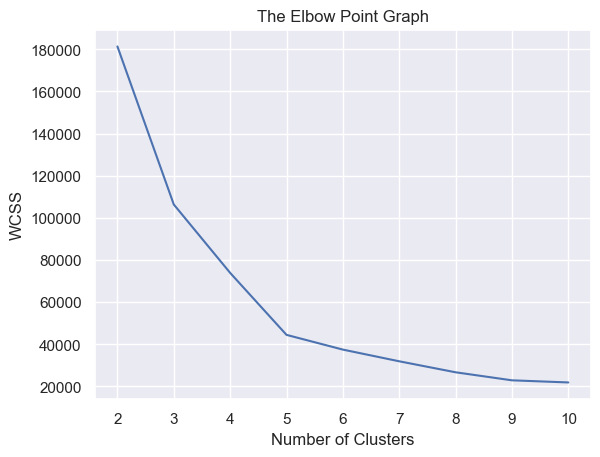

In [12]:
sns.set()
plt.plot(range(2,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()
#Clusters = 5

In [8]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0,n_init=2)

# return a label for each data point based on their cluster
Y = kmeans.fit_predict(X)

print(Y)

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


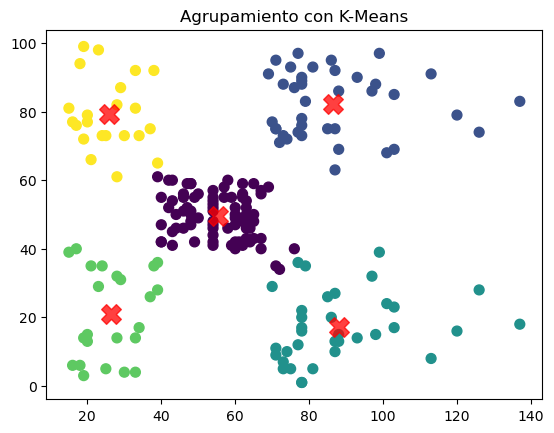

In [9]:
# Visualizar los clústeres
plt.scatter(X[:, 0], X[:, 1], c=Y, s=50, cmap='viridis')

# Marcar los centroides
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('Agrupamiento con K-Means')
plt.show()

In [10]:
from sklearn.cluster import KMeans

input_data = (60, 50)  # Example: Annual Income = 60k$, Spending Score = 50

# Convert the input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape the data as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Make prediction using the trained K-Means model
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=0)  # Example model initialization
kmeans_model.fit(X)  # Assuming 'X' is the data used for training

# Predict the cluster for the new input data
cluster_prediction = kmeans_model.predict(input_data_reshaped)[0]

# Assign names to clusters based on their characteristics
cluster_names = {
    0: "Low Income, Low Spending",
    1: "Low Income, High Spending",
    2: "Average Income, Average Spending",
    3: "High Income, Low Spending",
    4: "High Income, High Spending"
}

# Get the name of the predicted cluster
predicted_cluster_name = cluster_names.get(cluster_prediction, "Unknown Cluster")

print(f'El cliente pertenece al cluster: {predicted_cluster_name}')

El cliente pertenece al cluster: Low Income, Low Spending


# EDA: base de datos full

In [11]:
costumers_df = pd.read_csv('Mall_Customers.csv') 
costumers_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1099188127,Male,19,15,39
1,1100189128,Male,21,15,81
2,1101190129,Female,20,16,6
3,1102191130,Female,23,16,77
4,1103192131,Female,31,17,40


In [17]:
costumers_df.shape

(812, 5)

In [18]:
costumers_df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [19]:
costumers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 812 entries, 0 to 811
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              812 non-null    int64 
 1   Gender                  812 non-null    object
 2   Age                     812 non-null    object
 3   Annual Income (k$)      812 non-null    object
 4   Spending Score (1-100)  812 non-null    object
dtypes: int64(1), object(4)
memory usage: 31.8+ KB


In [12]:
data_df = costumers_df.drop('CustomerID', axis=1)
data_df = data_df.drop_duplicates()
data_df = data_df.reset_index(drop=True)

In [13]:
data_df.replace("?", np.nan, inplace = True)
data_df.tail(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
795,Female,62,57,NaN
796,Female,44,79,NaN
797,Female,23,94,NaN
798,Female,55,78,NaN
799,Male,29,118,NaN


In [91]:
data_df.isna().sum()

Gender                     0
Age                       10
Annual Income (k$)        30
Spending Score (1-100)    60
dtype: int64

**Lidiar con valores perdidos**
Cuando tenemos un *dataset* con valores perdidos, podemos tomar las siguientes decisiones:

* Eliminar datos:
 *   Eliminar toda la(s) fila(s)
 *   Eliminar toda la columna

* Reemplazar datos:
 *   Reemplazar por la media (o promedio)
 *   Reemplazar por la frecuencia
 *   Reemplazar en función de otras funciones



In [14]:
#Lidiar con valores faltantes de la columna Age
# Probando eliminar las filas incompletas
data_df.dropna(subset=['Age'], axis=0, inplace=True)

In [15]:
data_df.reset_index(drop=True, inplace=True)

In [16]:
#Verifica los reemplazos de Age
data_df['Age'].isna().sum()

0

In [17]:
#Lidiar con valores faltantes de la columna Annual Income (k$)
# Probando reemplazar por la frecuencia
data_df['Annual Income (k$)'].mode()[0]

'78'

In [18]:
data_df['Annual Income (k$)'].replace(np.nan, '78', inplace=True)

In [19]:
#Verifica los reemplazos de Annual Income (k$)
data_df['Annual Income (k$)'].isna().sum()

0

In [20]:
#Lidiar con valores faltantes de la columna Spending Score (1-100)
# Probando reemplazar por la media
avg = data_df['Spending Score (1-100)'].astype("float").mean()
print(avg)

70.90821917808219


In [21]:
data_df['Spending Score (1-100)'].replace(np.nan, avg, inplace=True)

In [22]:
data_df['Spending Score (1-100)'].isna().sum()

0

In [23]:
#Verifica todos los cambios realizados imprimiendo las ultimas 100 filas del dataset
data_df.tail(100)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
690,Male,49,25,86
691,Female,68,78,60
692,Male,70,36,72
693,Male,41,52,89
694,Female,32,75,79
...,...,...,...,...
785,Female,62,57,70.908219
786,Female,44,79,70.908219
787,Female,23,94,70.908219
788,Female,55,78,70.908219


In [24]:
data_df[['Age','Annual Income (k$)', 'Spending Score (1-100)']] = data_df[['Age','Annual Income (k$)', 'Spending Score (1-100)']].astype('int64')

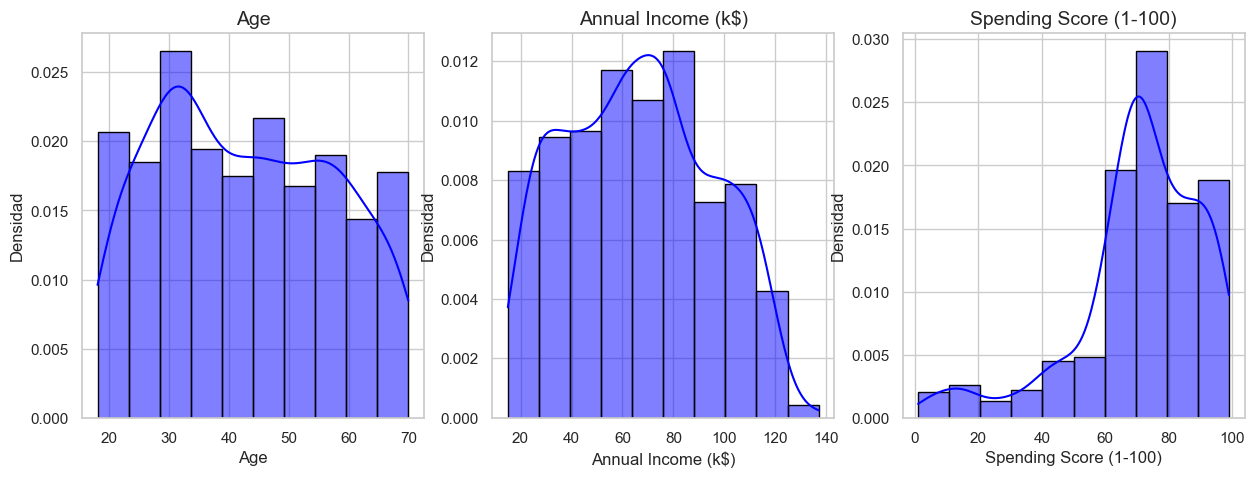

In [25]:
# Crear histogramas y curvas de densidad para cada columna
columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Establecer el estilo de seaborn
sns.set(style='whitegrid')
plt.figure(figsize=(15, 5))
# Graficar cada columna
n=1
for col in columns:
    
    plt.subplot(1,3,n)
    n+=1
    # Crear histograma y curva de densidad con seaborn
    sns.histplot(data_df[col], kde=True, bins=10, color='blue', stat='density', edgecolor='black')
    
    # Añadir etiquetas y título
    plt.title(f'{col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    



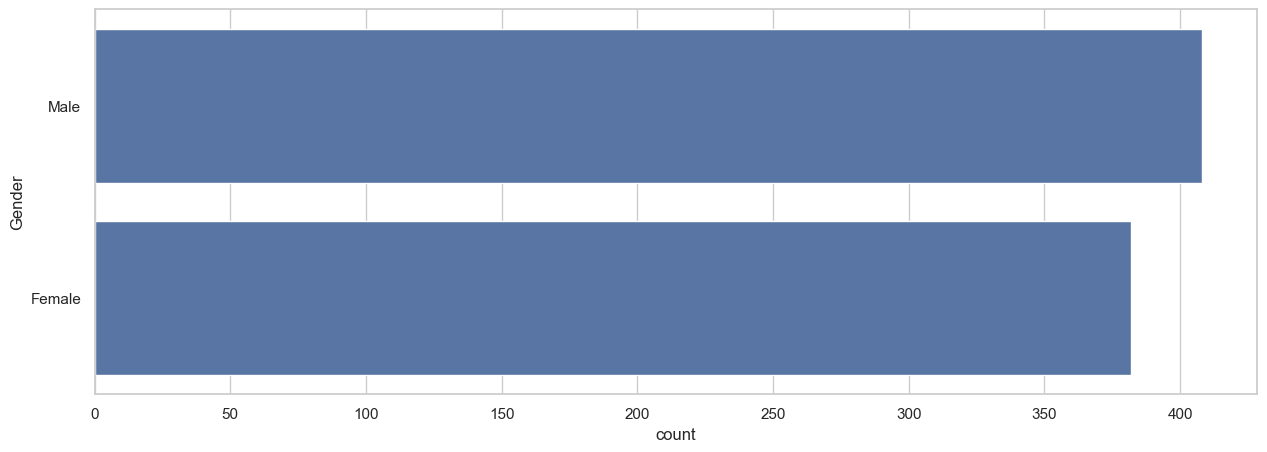

In [34]:
plt.figure(1 , figsize = (15 , 5))
sns.countplot(y = 'Gender' , data = data_df)
plt.show()

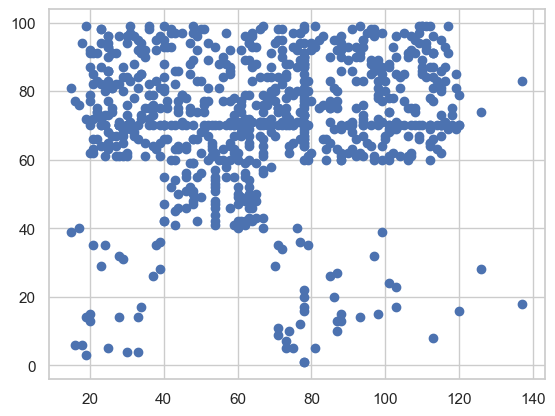

In [26]:
plt.scatter(data_df['Annual Income (k$)'], data_df['Spending Score (1-100)'])

# Análisis de Componentes Principales (PCA)

Es una técnica de reducción de dimensionalidad que busca simplificar un conjunto de datos con muchas variables mientras conserva la mayor cantidad posible de información relevante.

### Proceso Matemático:

1. **Centrado de Datos**: Se restan las medias de cada variable para centrar los datos alrededor del origen (0).
   
2. **Matriz de Covarianza**: Calculamos la matriz de covarianza de los datos centrados. Esta matriz mide cómo las variables varían juntas.

3. **Autovectores y Autovalores**: Obtenemos los **autovectores** y **autovalores** de la matriz de covarianza. Los autovectores representan las direcciones de mayor variación (llamadas **componentes principales**), y los autovalores indican la magnitud de esta variación.

4. **Proyección**: Los datos se proyectan sobre los primeros \( k \) autovectores (componentes principales) que retienen la mayor variabilidad. Matemáticamente, esto reduce la dimensionalidad manteniendo la mayor cantidad de información posible.

### Intuición:

PCA transforma el conjunto de datos a un nuevo espacio donde las dimensiones están desacopladas, ordenando las direcciones según la variabilidad de los datos. Esto simplifica el análisis, eliminando redundancias y reduciendo el ruido.

Por ejemplo, si los datos originales están en un espacio 3D, pero la mayor variación está en un plano 2D, PCA puede reducir la dimensionalidad a ese plano mientras conserva la mayor parte de la información relevante.

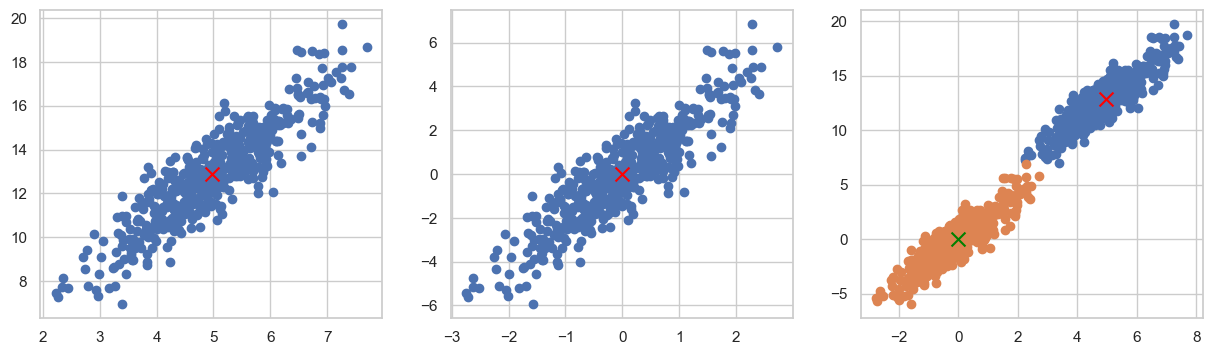

In [36]:

from sklearn.decomposition import PCA

# Sample Data (2D points)
np.random.seed(0)
x = np.random.normal(size=500)+5
y = 2 * x + np.random.normal(size=500)+3
# Concatenate x and y to create a 2D dataset
data = np.column_stack((x, y))

# Centering the Data (important for PCA)
data_mean = np.mean(data, axis=0)
data_centered = data - data_mean
plt.figure(figsize=(15, 4)) 
plt.subplot(131)
plt.scatter(data[:, 0],data[:, 1])
plt.scatter(data_mean[ 0], data_mean[1], marker="x", color="red", s=100)

plt.subplot(132)
plt.scatter(data_centered[:, 0],data_centered[:, 1])
plt.scatter(0, 0, marker="x", color="red", s=100)

plt.subplot(133)
plt.scatter(data[:, 0],data[:, 1])
plt.scatter(data_centered[:, 0],data_centered[:, 1])

plt.scatter(data_mean[ 0], data_mean[1], marker="x", color="red", s=100)
plt.scatter(0, 0, marker="x", color="green", s=100)

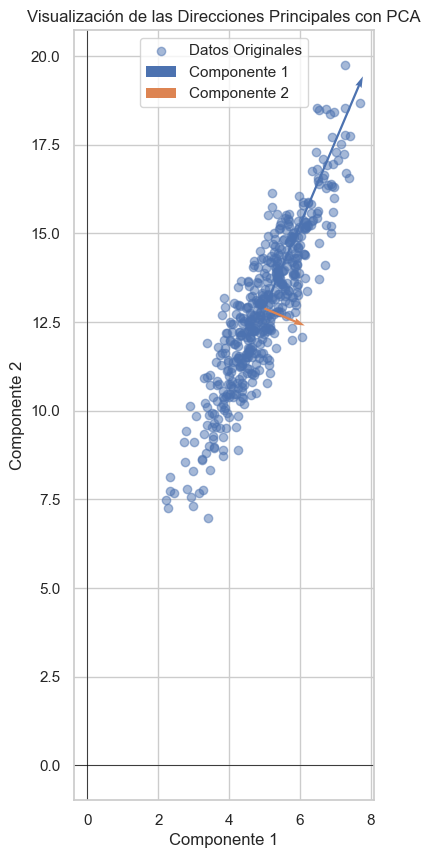

In [40]:
pca = PCA(n_components=2)
pca.fit(data)

# Obtener los componentes principales y las varianzas
components = pca.components_  # Vectores direccionales
explained_variance = pca.explained_variance_  # Varianza explicada en cada componente

# Visualizar los datos originales
plt.figure(figsize=(5, 10))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label='Datos Originales')

# Dibujar los componentes principales
for i, (component, variance) in enumerate(zip(components, explained_variance)):
    start = pca.mean_
    # El largo de la flecha está escalado por la raíz cuadrada de la varianza explicada
    end = pca.mean_ + component * 3 * np.sqrt(variance)  # Escalar la dirección por la varianza
    plt.quiver(*start, *(end - start), angles='xy', scale_units='xy', scale=1, color=f'C{i}', label=f'Componente {i+1}')

# Configuración de la visualización
plt.title('Visualización de las Direcciones Principales con PCA')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

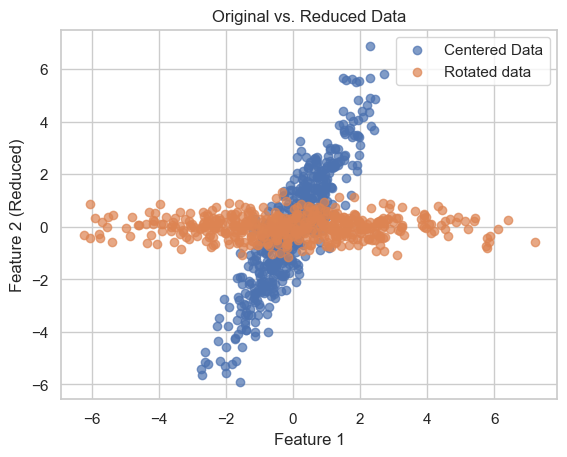

In [41]:
# Transform data to lower-dimensional space
reduced_data = pca.transform(data)
# Visualize Original vs. Reduced Data
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.7, label='Centered Data')
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.7, label='Rotated data')

plt.title("Original vs. Reduced Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2 (Reduced)")
plt.legend()
plt.grid(True)
plt.show()

Las componentes principales en PCA (Análisis de Componentes Principales) son una combinación lineal de las variables explicativas (variables originales o *features*). Matemáticamente, esto se puede demostrar de la siguiente manera:

### Definición:

Dado un conjunto de variables explicativas $ X_1, X_2, \dots, X_p $, las componentes principales $Z_1, Z_2, \dots, Z_k $ son combinaciones lineales de estas variables, de la forma:

$
Z_1 = a_{11}X_1 + a_{12}X_2 + \dots + a_{1p}X_p
$

$
Z_2 = a_{21}X_1 + a_{22}X_2 + \dots + a_{2p}X_p
$

$
\vdots
$

$
Z_k = a_{k1}X_1 + a_{k2}X_2 + \dots + a_{kp}X_p
$

donde los coeficientes $ a_{ij} $ representan los pesos (cargas) que determinan cuánto contribuye cada variable explicativa $ X_j $ a la componente principal $ Z_i $.

### Interpretación:

- Las componentes principales son direcciones en el espacio de las variables originales que maximizan la varianza de los datos.
- Cada componente principal es ortogonal a las demás (no correlacionadas) y captura la mayor cantidad posible de varianza restante en los datos.
- Los coeficientes $ a_{ij} $ indican la contribución de cada variable explicativa a la correspondiente componente principal.

Por lo tanto, **las componentes principales son combinaciones lineales de las variables explicativas originales, con los coeficientes determinados por los vectores propios de la matriz de covarianza**.

In [42]:
costumers_df = pd.read_csv('Mall_Customers_small.csv') 
costumers_df.head()
# drop Customer id 
data_df = costumers_df.drop('CustomerID', axis=1)
data_df.head(2)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81


In [43]:
train_X, test_X = train_test_split(data_df, test_size=0.2, random_state=42)

print(len(train_X), "train +", len(test_X), "test")

160 train + 40 test


In [44]:
# lets take copy of the data 
df = train_X.copy()

In [45]:
le = LabelEncoder()
le.fit(df.Genre)
df.loc[:,'Genre'] = le.transform(df.Genre)
df.head(3)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
79,0,49,54,42
197,1,32,126,74
38,0,36,37,26


In [46]:
train_X.head(3)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
79,Female,49,54,42
197,Male,32,126,74
38,Female,36,37,26


In [47]:
from sklearn.pipeline import make_pipeline   
from sklearn.preprocessing import StandardScaler

In [48]:
# Create scaler: scaler
scaler = StandardScaler()
scaler.fit(df)
# transform
data_scaled = scaler.transform(df)
data_scaled[0]

array([-0.87077078,  0.73027906, -0.24190423, -0.37113766])

In [49]:
pca = PCA()

# fit PCA
pca.fit(data_scaled)
# PCA features
features = range(pca.n_components_)
# PCA transformed data
data_pca = pca.transform(data_scaled)
pca.explained_variance_ratio_

array([0.33107688, 0.26720006, 0.22991261, 0.17181045])

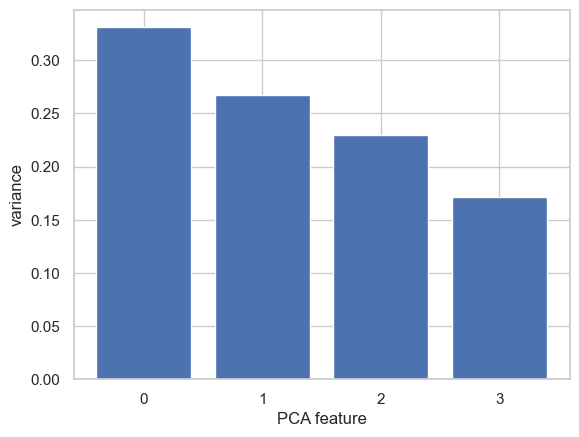

In [50]:
plt.bar(features, pca.explained_variance_ratio_)
plt.xticks(features)
plt.ylabel('variance')
plt.xlabel('PCA feature')
plt.show()

In [51]:
pca2 = PCA(n_components=2, svd_solver='full')
# fit PCA
pca2.fit(data_scaled)

# PCA transformed data
data_pca2 = pca2.transform(data_scaled)
print(data_pca2.shape)

(160, 2)


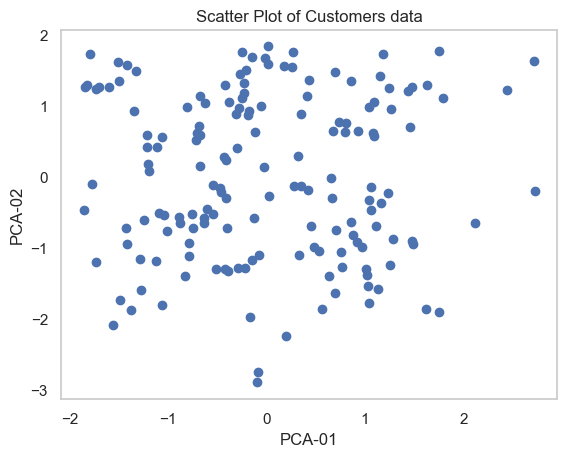

In [52]:
xs = data_pca2[:,0]
ys = data_pca2[:,1]
plt.scatter(ys, xs)

plt.grid(False)
plt.title('Scatter Plot of Customers data')
plt.xlabel('PCA-01')
plt.ylabel('PCA-02')

plt.show()

In [53]:
#  finding elbow value for different number of clusters.
X = data_pca2
inertia = []
for n in range(1 , 11):
    algorithm = (KMeans(n_clusters = n ,init='k-means++',random_state= 42 ) )
    algorithm.fit(X)
    inertia.append(algorithm.inertia_)    

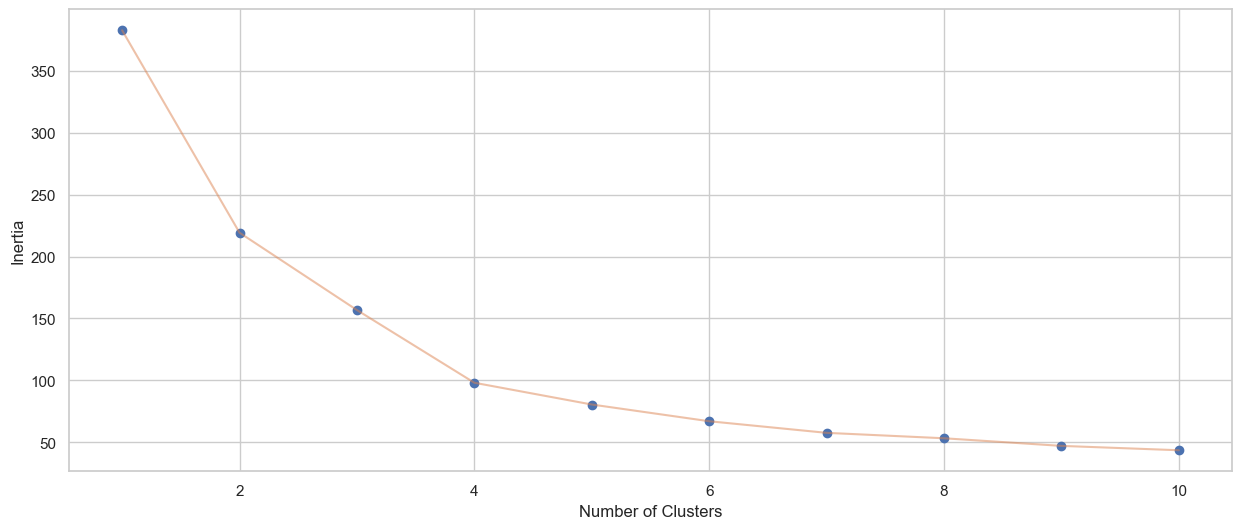

In [54]:
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

In [55]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

In [56]:
# Build pipeline
pipeline = make_pipeline(scaler, pca2, kmeans)
# fit the model to the scaled dataset
model_fit = pipeline.fit(df)
model_fit

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=2, svd_solver='full')),
                ('kmeans', KMeans(n_clusters=5, random_state=0))])

In [57]:
train_X

,Genre,Age,Annual Income (k$),Spending Score (1-100)
79,Female,49,54,42
197,Male,32,126,74
38,Female,36,37,26
24,Female,54,28,14
122,Female,40,69,58
...,...,...,...,...
106,Female,66,63,50
14,Male,37,20,13
92,Male,48,60,49
179,Male,35,93,90


In [58]:
labels = model_fit.predict(df)
train_X['Clusters'] = labels
# Number of data points for each feature in each cluster
train_X.groupby('Clusters').count()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,,
0,29,29,29,29
1,25,25,25,25
2,20,20,20,20
3,40,40,40,40
4,46,46,46,46


In [59]:
train_X

,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
79,Female,49,54,42,3
197,Male,32,126,74,0
38,Female,36,37,26,3
24,Female,54,28,14,3
122,Female,40,69,58,4
...,...,...,...,...,...
106,Female,66,63,50,3
14,Male,37,20,13,3
92,Male,48,60,49,1
179,Male,35,93,90,0


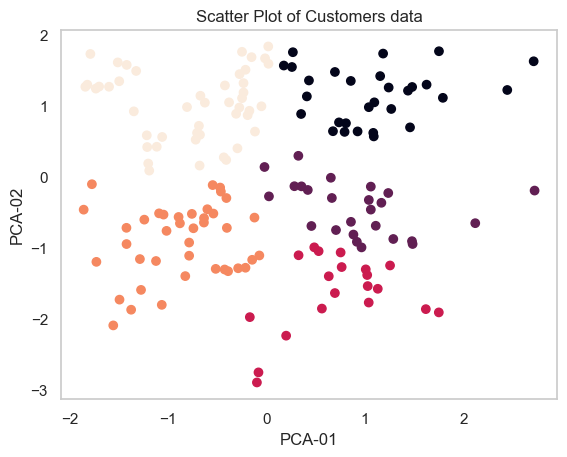

In [60]:
xs = data_pca2[:,0]
ys = data_pca2[:,1]
#zs = train_X.iloc[:,2]
plt.scatter(ys, xs,c=labels)
#plt.scatter(ys, zs, c=labels)

plt.grid(False)
plt.title('Scatter Plot of Customers data')
plt.xlabel('PCA-01')
plt.ylabel('PCA-02')

plt.show()

In [61]:
# predict the labels
le.fit(test_X.Genre)

#update df2 with transformed values of gender
test_X.loc[:,'Genre'] = le.transform(test_X.Genre)

labels_test = model_fit.predict(test_X)
test_X['Clusters'] = labels_test

labels_test


array([0, 4, 2, 1, 2, 4, 4, 1, 2, 4, 3, 1, 4, 4, 2, 0, 3, 3, 2, 0, 4, 3,
       3, 3, 0, 2, 4, 3, 4, 4, 4, 2, 1, 0, 1, 1, 4, 0, 2, 3], dtype=int32)

In [62]:
test_X.groupby('Clusters').count()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,,
0,6,6,6,6
1,6,6,6,6
2,8,8,8,8
3,8,8,8,8
4,12,12,12,12


In [63]:
cluster_heatmap_df = train_X.groupby('Clusters')[['Age','Annual Income (k$)','Spending Score (1-100)']].median()


In [64]:
cluster_heatmap_df

,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,
0,32.0,78.0,83.0
1,38.0,77.0,28.0
2,59.0,54.0,44.5
3,49.0,48.0,42.0
4,28.5,44.5,73.0


In [65]:
train_X[train_X['Genre'] == 'Female'].groupby('Clusters').count()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,,
0,6,6,6,6
1,7,7,7,7
2,1,1,1,1
3,38,38,38,38
4,39,39,39,39


In [66]:
train_X[train_X['Genre'] == 'Male'].groupby('Clusters').count()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,,
0,23,23,23,23
1,18,18,18,18
2,19,19,19,19
3,2,2,2,2
4,7,7,7,7


In [67]:
train_X.groupby(['Clusters']).count()['Genre']

Clusters
0    29
1    25
2    20
3    40
4    46
Name: Genre, dtype: int64

In [68]:
cluster_heatmap_df['FemaleRatio'] = train_X[train_X['Genre'] == 'Female'].groupby('Clusters').count()['Genre'] / train_X.groupby(['Clusters']).count()['Genre'] * 100
cluster_heatmap_df

,Age,Annual Income (k$),Spending Score (1-100),FemaleRatio
Clusters,,,,
0,32.0,78.0,83.0,20.689655
1,38.0,77.0,28.0,28.000000
2,59.0,54.0,44.5,5.000000
3,49.0,48.0,42.0,95.000000
4,28.5,44.5,73.0,84.782609


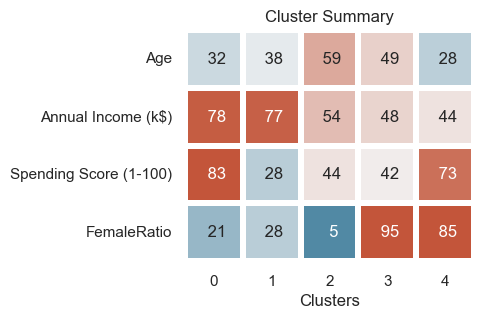

In [69]:
heatcmap = sns.diverging_palette(230, 20, as_cmap=True)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.heatmap(cluster_heatmap_df.T, 
    square=True,
    linewidth=3,
    vmax=80, 
    vmin=1,
    cmap=heatcmap,
    cbar=False, 
    annot=True,
    fmt='3.0f',
    ax=ax,
);

ax.set_title('Cluster Summary');
plt.tight_layout()

## Detección de Anomalías: Revelando lo Inusual

La detección de anomalías es una técnica de aprendizaje automático que identifica patrones inusuales o puntos de datos que se desvían significativamente del comportamiento esperado. Es como encontrar los valores atípicos en un conjunto de datos. Estas anomalías pueden ser indicativas de fraude, fallos en el sistema u otros eventos críticos.

Existen dos enfoques principales para la detección de anomalías:

1. **Aprendizaje Supervisado:** Este enfoque requiere datos etiquetados, donde algunos puntos de datos ya están clasificados como normales o anómalos. El modelo aprende a partir de estos datos etiquetados y luego los utiliza para identificar anomalías en nuevos datos no vistos.

2. **Aprendizaje No Supervisado:** Este enfoque es más común para la detección de anomalías porque los datos de anomalías suelen ser escasos. El modelo analiza la estructura inherente de los datos no etiquetados para identificar desviaciones de los patrones esperados.

A continuación, una introducción paso a paso a la detección de anomalías con código en Python utilizando un conjunto de datos de prueba:

**1. Generación de Datos de Prueba:**
Este código genera un conjunto de datos 2D con algunos valores atípicos (puntos de datos con valores significativamente más altos o más bajos en comparación con la mayoría).

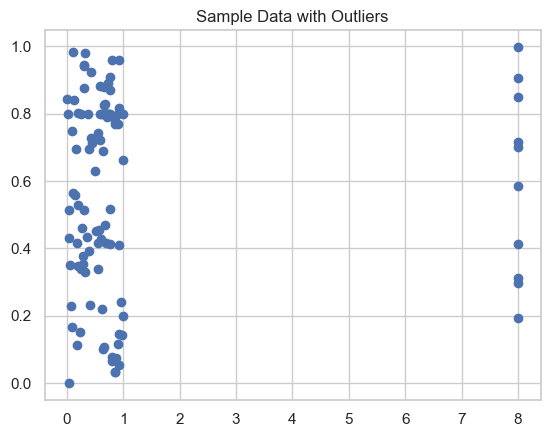

In [71]:
import numpy as np

# Simulate normal data with some outliers
data = np.random.rand(100, 2)  # 100 data points with 2 features

# Introduce outliers on the x-axis
data[10:20, 0] = 8  # Outliers with higher x-values

# Introduce outliers on the y-axis
data[30:40, 1] = 0.8  # Outliers with lower y-values

# Plot the data
plt.scatter(data[:, 0], data[:, 1])
plt.title("Sample Data with Outliers")
plt.show()

**2. Unsupervised Anomaly Detection with Isolation Forest:**

This code uses Isolation Forest, an unsupervised anomaly detection algorithm. It isolates anomalies by randomly partitioning the data. Points requiring fewer splits are likely normal, while outliers require many splits. The code calculates anomaly scores and highlights data points exceeding a specific threshold (you can adjust this threshold based on your needs).



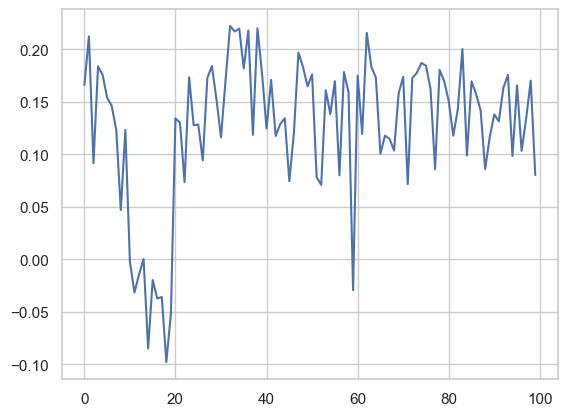

In [72]:

from sklearn.ensemble import IsolationForest

# Define the anomaly score threshold (optional)
isolation_forest = IsolationForest(contamination=0.1)  # Expect 10% anomalies

# Train the model on the data
isolation_forest.fit(data)

# Predict anomaly scores for each data point
anomaly_scores = isolation_forest.decision_function(data)

# Higher scores indicate higher anomaly likelihood
anomaly_threshold = 0  # Example threshold (can be tuned)
anomaly_indices = np.where(anomaly_scores < anomaly_threshold)[0]
plt.plot(anomaly_scores)

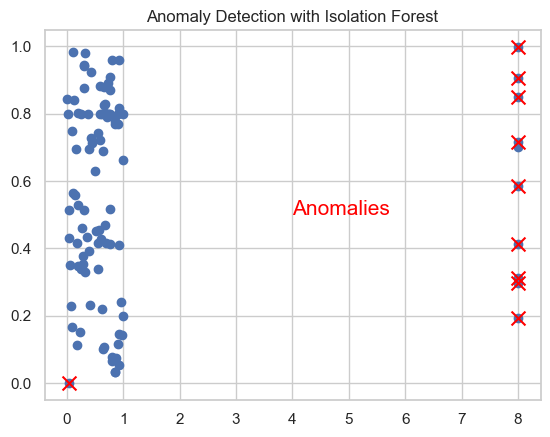

In [73]:

# Plot the data with highlighted anomalies
plt.scatter(data[:, 0], data[:, 1])
plt.scatter(data[anomaly_indices, 0], data[anomaly_indices, 1], marker="x", color="red", s=100)
plt.title("Anomaly Detection with Isolation Forest")

# Add a text annotation for enhanced clarity
plt.annotate("Anomalies", (4, 0.5), fontsize=15, color="red")


plt.show()

**3. Supervised Anomaly Detection (Example with One-Class SVM):**

While unsupervised methods are common, supervised learning can also be used if labeled anomaly data is available. Here's a basic example with a One-Class SVM:
This code demonstrates a One-Class SVM, which learns a boundary around the normal data. Points falling outside this boundary are considered anomalies. Note that supervised anomaly detection heavily relies on the quality and representativeness of the labeled data.


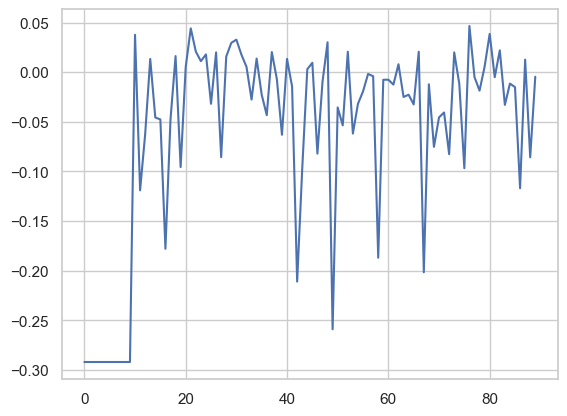

In [74]:
from sklearn.svm import OneClassSVM

# Label the first 10 data points as normal (assuming some labeled data exists)
normal_data = data[:10]
remaining_data = data[10:]

# Train the One-Class SVM on the normal data
one_class_svm = OneClassSVM(nu=0.1)  # nu: fraction of outliers allowed
one_class_svm.fit(normal_data)

# Predict anomaly scores for the remaining data
anomaly_scores = one_class_svm.decision_function(remaining_data)

plt.plot(anomaly_scores)

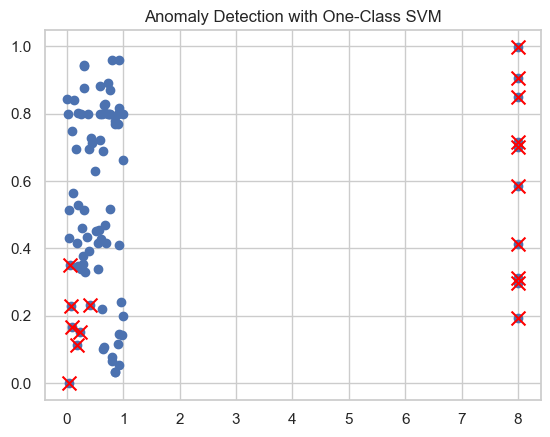

In [75]:
# Similar to Isolation Forest, higher scores indicate anomalies
anomaly_threshold = -0.1  # Example threshold (can be tuned)
plt.scatter(remaining_data[:, 0], remaining_data[:, 1])
anomaly_indices = np.where(anomaly_scores < anomaly_threshold)[0]  # Example threshold adjustment
plt.scatter(remaining_data[anomaly_indices, 0], remaining_data[anomaly_indices, 1], marker="x", color="red", s=100)
plt.title("Anomaly Detection with One-Class SVM")
plt.show()
